In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv('Sales_data.csv',encoding='latin-1')


In [3]:
df1.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
#DataSet Metadata Analysis
print("Rows , Cols: ",df1.shape)
print("\ncolumns")
print(df1.columns.tolist())
print('Duplicate Values: ',df1.duplicated().sum())
print("\nMissing Values (Top 20): ")
print(df1.isnull().sum().sort_values(ascending=False).head(20))

Rows , Cols:  (180519, 53)

columns
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produ

In [5]:
# Data Cleaning
columns_to_drop = ['Product Description',
'Product Image',
'Customer Email',
'Customer Password',
'Customer Fname',
'Customer Lname',
'Customer Street',
'Customer Zipcode',
'Order Zipcode',
'Longitude',
'Latitude',
'Order Item Cardprod Id',
'Order Item Id',
'Order Item Discount',
'Order Item Discount Rate',
'Order Item Product Price',
'Order Item Quantity',
'Order Item Total',
'Category Id',
'Department Id',
'Order Id',
'Order Customer Id',
'Customer Id',
'Product Card Id',
'Product Category Id',
'Benefit per order', # identical to Order Profit Per Order
'Product Status', # have only one value,
'Customer City',
'Order City',
'Order Country',
'Order State',
'Customer State',
'Market']

#dropping columns that are either fully missing, redundant, or have only one value (and thus no variance)
df1 = df1.drop(columns=columns_to_drop)
df1 = df1[df1['Delivery Status'] != 'Shipping canceled']

In [6]:
df1.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,1/13/2018 11:24,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


In [7]:
#Formating Into pandas datetime
df1['order date (DateOrders)'] = pd.to_datetime(df1['order date (DateOrders)'], format='%m/%d/%Y %H:%M')
df1['shipping date (DateOrders)'] = pd.to_datetime(df1['shipping date (DateOrders)'], format='%m/%d/%Y %H:%M')

In [8]:
print("Rows , Cols: ",df1.shape)
print("\ncolumns")
print(df1.columns.tolist())
print('Duplicate Values: ',df1.duplicated().sum())
print("\nMissing Values (Top 5): ")
print(df1.isnull().sum().sort_values(ascending=False).head(5))

Rows , Cols:  (172765, 20)

columns
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']
Duplicate Values:  0

Missing Values (Top 5): 
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [9]:
# Categorical Data Analysis

for col in df1.select_dtypes(include=['object']).columns:
  if df1[col].nunique() < 10:
    print(f"{col}: {df1[col].unique()}")
    print(f"{col}: {df1[col].value_counts()}\n")
  else:
    print(f"\n{col}: {len(df1[col].unique())} unique values")


Type: <StringArray>
['DEBIT', 'TRANSFER', 'CASH', 'PAYMENT']
Length: 4, dtype: str
Type: Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Delivery Status: <StringArray>
['Advance shipping', 'Late delivery', 'Shipping on time']
Length: 3, dtype: str
Delivery Status: Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64


Category Name: 50 unique values
Customer Country: <StringArray>
['Puerto Rico', 'EE. UU.']
Length: 2, dtype: str
Customer Country: Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment: <StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str
Customer Segment: Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64


Department Name: 11 unique values

Order Region: 23 unique values
Order Status: <StringArray>
[       'COMPLETE',    

C:\Users\Asus\AppData\Local\Temp\ipykernel_21172\3386917787.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df1.select_dtypes(include=['object']).columns:


Shipping Mode: <StringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str
Shipping Mode: Shipping Mode
Standard Class    103153
Second Class       33806
First Class        26513
Same Day            9293
Name: count, dtype: int64



In [10]:
# Feature Engineering
df1['Order Processing Time'] = df1['shipping date (DateOrders)'] - df1['order date (DateOrders)']
df1['Order Processing Time'] = df1['Order Processing Time'].dt.days
df1['Delay'] = df1['Order Processing Time'] - df1['Days for shipment (scheduled)']
df1['Is Delayed'] = df1['Delay'].apply(lambda x: 1 if x > 0 else 0)

df1['order day'] = df1['order date (DateOrders)'].dt.day_name()
df1['order month'] = df1['order date (DateOrders)'].dt.month
df1['order hour'] = df1['order date (DateOrders)'].dt.hour

In [11]:
df1.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is Delayed,order day,order month,order hour
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,0,Wednesday,1,22
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,1,Saturday,1,12
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,0,Saturday,1,12
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,0,Saturday,1,11
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,0,Saturday,1,11


In [12]:
(df1['Days for shipping (real)'] == df1['Order Processing Time']).value_counts()

True     168311
False      4454
Name: count, dtype: int64

In [13]:
df1.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,Is Delayed,order month,order hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,0.547119,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,0.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,1.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,0.497776,3.405593,6.927276


In [14]:
df1['Profitability Flag'] = np.where(df1['Order Profit Per Order'] > 0, 'Profit', np.where(df1['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df1['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

<Axes: xlabel='Profitability Flag', ylabel='count'>

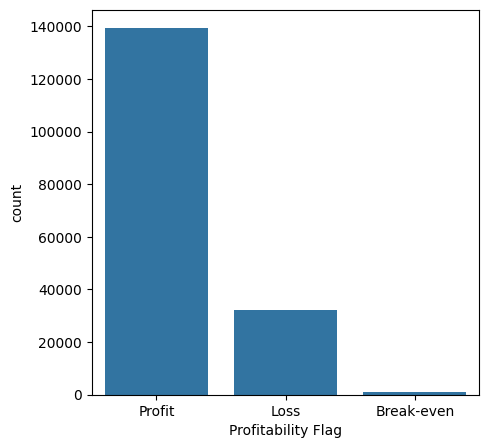

In [15]:
#Visualizing The Profit, Loss and Break-Even Counts

plt.figure(figsize=(5, 5))
sns.countplot(x='Profitability Flag', data=df1)

Text(0.5, 1.0, 'Profitability Flag Distribution')

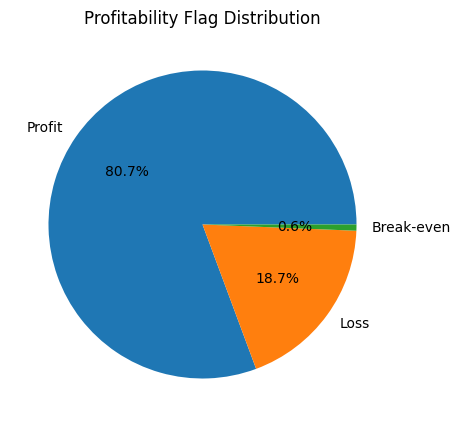

In [16]:
plt.figure(figsize=(5, 5))
plt.pie(df1['Profitability Flag'].value_counts(), labels=df1['Profitability Flag'].unique(), autopct='%1.1f%%')
plt.title('Profitability Flag Distribution')

In [17]:
# Delayed Delivery Analysis -

def format_func(value):
  if value >= 1e6:
    return f'{value/1e6:.1f}M $'
  elif value >= 1e3:
    return f'{value/1e3:.1f}K $'
  else:
    return f'{value:.0f} $'

df_delayed = df1[df1['Is Delayed'] == 1]
Metrics = {}
Metrics['Total Delayed Orders'] = len(df_delayed)
Metrics['Total Orders'] = len(df1)
Metrics['90% Percentile of Delayed Orders'] = df_delayed['Delay'].quantile(0.9)

# Calculate raw numeric values for profit/loss
total_profit_raw = df1[df1['Profitability Flag'] == 'Profit']['Order Profit Per Order'].sum()
total_loss_raw = df1[df1['Profitability Flag'] == 'Loss']['Order Profit Per Order'].sum()
profit_delayed_raw = df_delayed[df_delayed['Order Profit Per Order'] > 0]['Order Profit Per Order'].sum()
loss_delayed_raw = df_delayed[df_delayed['Order Profit Per Order'] < 0]['Order Profit Per Order'].sum()
Delayed_Orders_Percentage = Metrics['Total Delayed Orders'] / Metrics['Total Orders'] * 100

# Store formatted values for display
Metrics['Total Profit'] = format_func(total_profit_raw)
Metrics['Total Loss'] = format_func(total_loss_raw)
Metrics['Profit of Delayed Orders'] = format_func(profit_delayed_raw)
Metrics['Loss of Delayed Orders'] = format_func(loss_delayed_raw)
Metrics['Delayed Orders Percentage'] = f"{round(Delayed_Orders_Percentage,2)}%"
Metrics['On Time Delivery %'] = f"{round(100 - Delayed_Orders_Percentage,2)}%"

# Calculate Loss Percentage of Delayed Orders using raw values
if total_loss_raw != 0:
    Metrics['Loss Percentage of Delayed Orders'] = f"{round((loss_delayed_raw / total_loss_raw) * 100, 2)}%"
else:
    Metrics['Loss Percentage of Delayed Orders'] = "0.00%" # Handle case where total_loss_raw is zero

# Calculate Profit Percentage Of Delayed Orders
if total_profit_raw != 0:
    Metrics['Profit Percentage of Delayed Orders'] = f"{round((profit_delayed_raw / total_profit_raw) * 100, 2)}%"
else:
    Metrics['Profit Percentage of Delayed Orders'] = "0.00%" # Handle case where total_profit_raw is zero

Metrics['Average Delay in Days'] = round(df_delayed['Delay'].mean(), 3)

print("------Busines KPI's------\n")
for key, value in Metrics.items():
  print(f"{key}: {value}")

------Busines KPI's------

Total Delayed Orders: 94523
Total Orders: 172765
90% Percentile of Delayed Orders: 3.0
Total Profit: 7.5M $
Total Loss: -3708393 $
Profit of Delayed Orders: 4.1M $
Loss of Delayed Orders: -2055610 $
Delayed Orders Percentage: 54.71%
On Time Delivery %: 45.29%
Loss Percentage of Delayed Orders: 55.43%
Profit Percentage of Delayed Orders: 54.71%
Average Delay in Days: 1.647


#Profitability Vs Delivery Time Analysis

In [18]:
profit_metrics = df1.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    ).reset_index()

In [19]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [20]:
delay_distribution = (
    df1['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

In [21]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


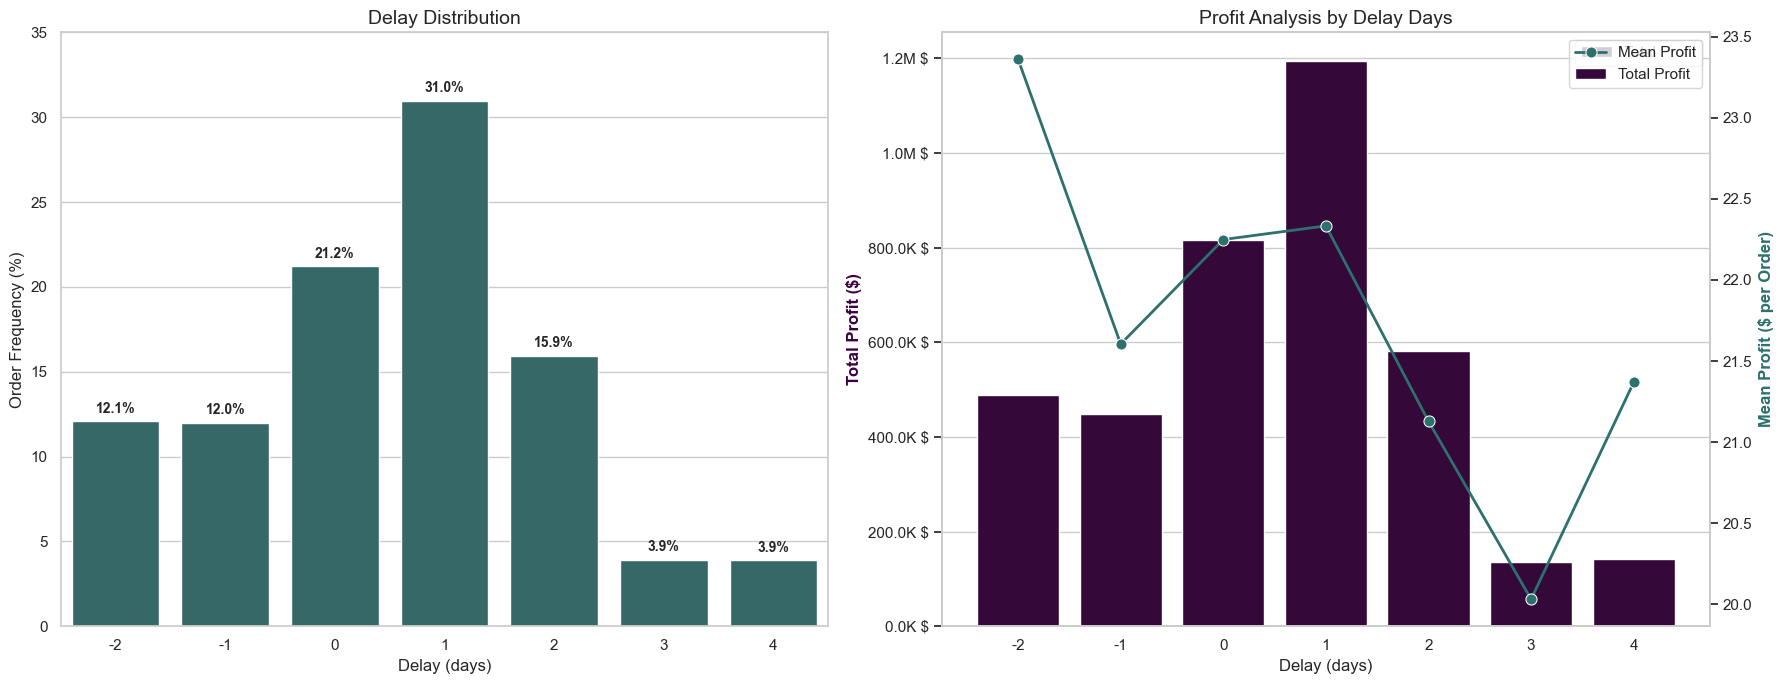

In [22]:
import matplotlib.ticker as ticker

# Set the style
sns.set_theme(style="whitegrid")

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Delay Distribution (Left) ---
# Using a specific teal-like color from the image
teal_color = "#2D706E"
sns.barplot(
    x='Delay', y='proportion', data=delay_distribution,
    ax=axes[0], color=teal_color
)

# Adding data labels as seen in the image
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                     ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Delay Distribution', fontsize=14)
axes[0].set_ylabel('Order Frequency (%)', fontsize=12)
axes[0].set_xlabel('Delay (days)', fontsize=12)
axes[0].set_ylim(0, 35) # Adjusted to match image scale

# --- Plot 2: Profit Analysis by Delay Days (Right) ---
# Primary Axis: Total Profit (Bars)
purple_color = "#3b0042"
sns.barplot(
    x='Delay', y='total_profit', data=profit_metrics,
    ax=axes[1], color=purple_color, label='Total Profit'
)

axes[1].set_title('Profit Analysis by Delay Days', fontsize=14)
axes[1].set_ylabel('Total Profit ($)', color=purple_color, fontweight='bold')
axes[1].set_xlabel('Delay (days)', fontsize=12)

# Format Y-axis to show K/M as in image
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e3:,.1f}K $' if x < 1e6 else f'{x/1e6:,.1f}M $'))

# Secondary Axis: Mean Profit (Line)
ax2 = axes[1].twinx()
sns.lineplot(
    x=range(len(profit_metrics)), # Use range to align with bar indices
    y='mean_profit', data=profit_metrics,
    ax=ax2, color='#2D706E', marker='o', markersize=8, linewidth=2, label='Mean Profit'
)

ax2.set_ylabel('Mean Profit ($ per Order)', color='#2D706E', fontweight='bold')
ax2.grid(False) # Clean look as per image

# --- Legend Handling ---
# Combine legends from both axes into one box
lines, labels = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines2 + lines, labels2 + labels, loc='upper right')

plt.tight_layout()
plt.show()

#BottleNeck Detection

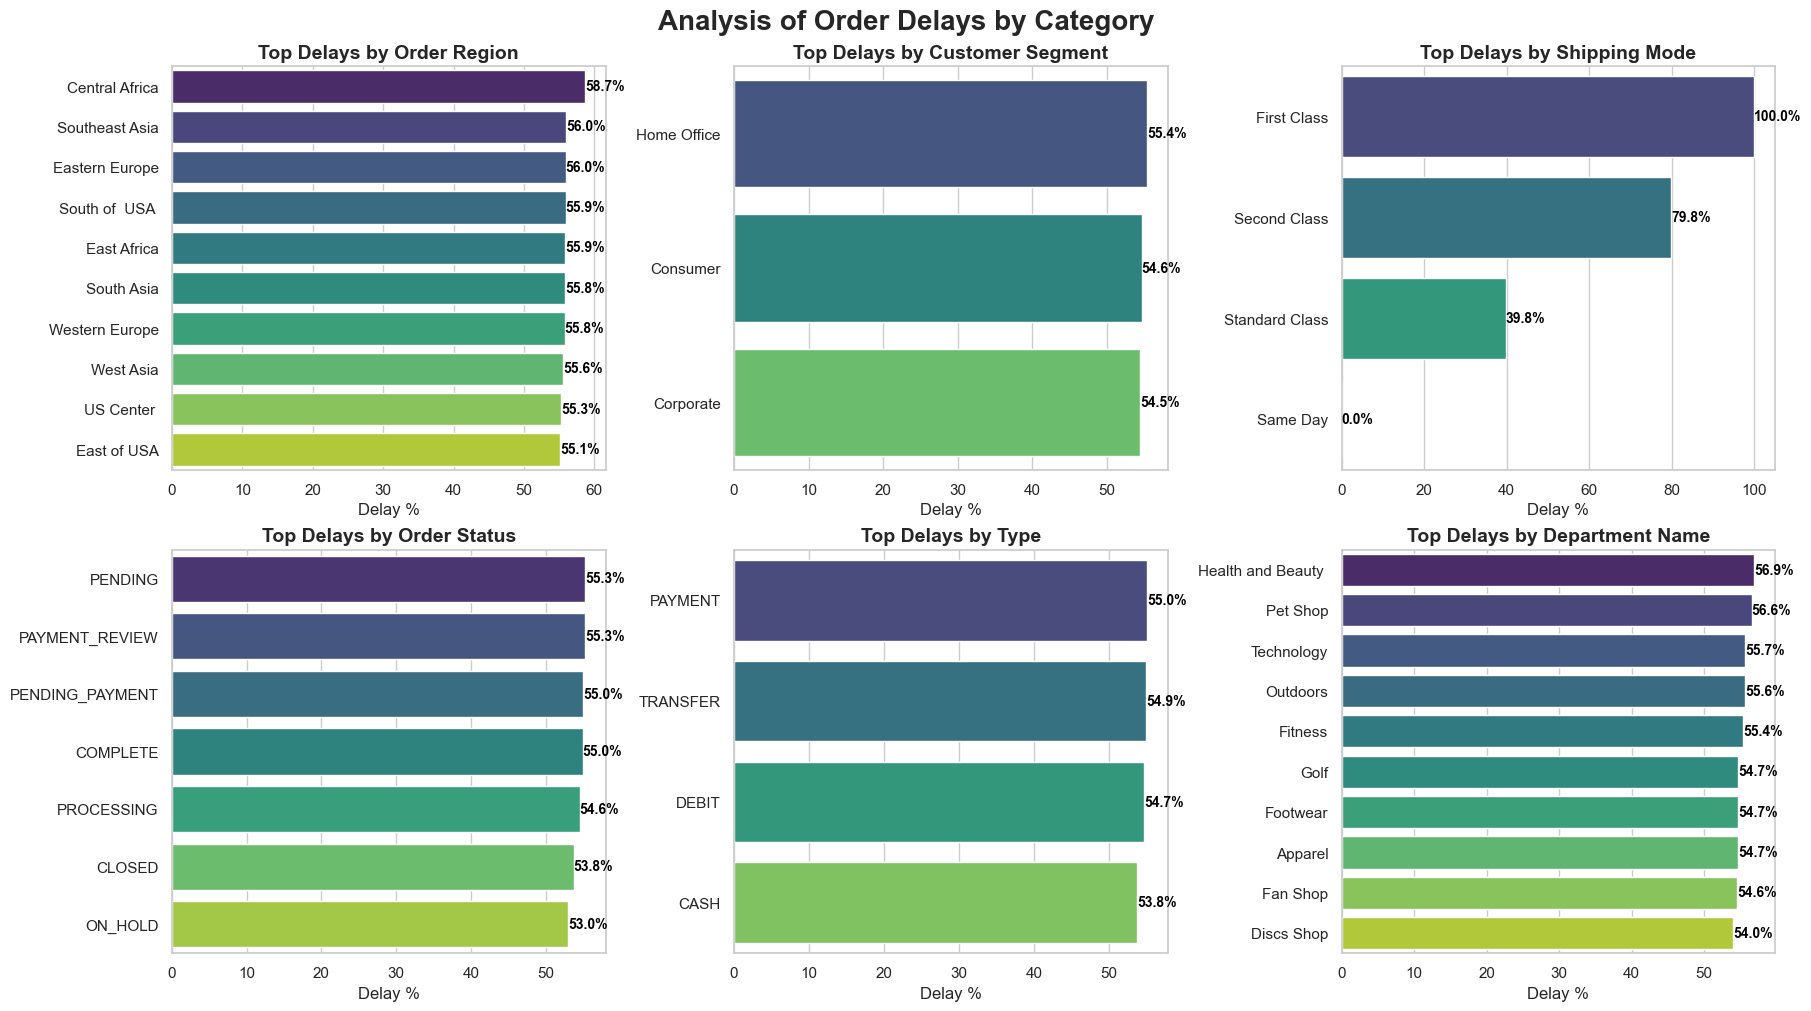

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compute_delay_pct_by_category(df, category, n=10):
    """Computes delay percentage and returns top n categories."""
    cat_df = df1.groupby(category).agg(
        total_orders=('Delay', 'count'), # 'Delay' is a column used for counting
        late_orders=('Is Delayed', 'sum') # 'Is Delayed' is boolean/binary (1 for delay)
    ).reset_index()

    # Calculate percentage
    cat_df['delay_pct'] = (cat_df['late_orders'] / cat_df['total_orders']) * 100

    # Sort and take top N
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(n)
    return cat_df

# Configuration
categories = ['Order Region', 'Customer Segment', 'Shipping Mode',
              'Order Status', 'Type', 'Department Name']

# Setup plotting grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
fig.suptitle('Analysis of Order Delays by Category', fontsize=20, fontweight='bold')
axes = axes.flatten()

for ax, category in zip(axes, categories):
    # Data Processing
    cat_df = compute_delay_pct_by_category(df1, category)

    # Visualization
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis',
        hue=category, # Added hue to avoid future warnings in Seaborn
        legend=False
    )

    # Aesthetics
    ax.set_title(f'Top Delays by {category}', fontsize=14, fontweight='semibold')
    ax.set_xlabel('Delay %')
    ax.set_ylabel('') # Removing redundant y-axis label for cleaner look

    # Annotation Logic
    # Improved: Placing text at the end of the bar or slightly inside based on value
    for i, row in cat_df.reset_index(drop=True).iterrows():
        val = row['delay_pct']
        x_pos = row['delay_pct']
        ax.text(
            x_pos, i,
            f"{val:.1f}%",
            va='center',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

plt.show()

#Root Cause Analysis

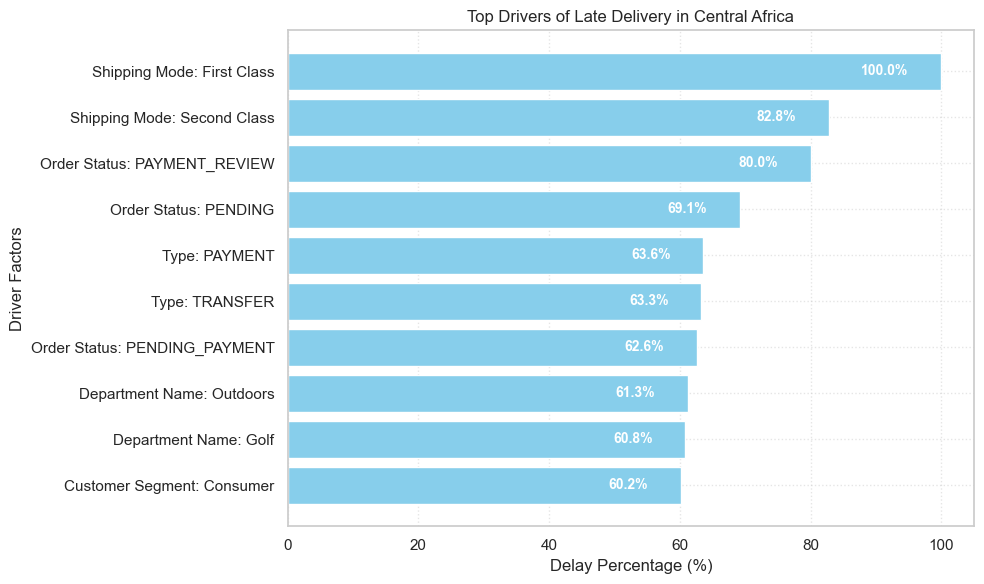

In [24]:
# Top drivers of late delivery by region
def top_drivers_for_region(region):
    # Filter dataframe for the specific region
    df_region = df1[df1['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        # Calculate delay percentage and identifier strings
        temp['delay_pct'] = (temp['late_orders'] / temp['total_orders']) * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + ": " + temp[factor].astype(str)

        # Keep only the relevant columns for concatenation
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    # Combine all drivers into one DataFrame
    final_df = pd.concat(all_factors)

    # Get the Top 10 drivers based on highest delay percentage
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    # Visualization
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'], color='skyblue')

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis() # Highest delay on top

    # Add text labels on the bars
    for bar in bars:
        width = bar.get_width()
        # Adjust text position (using 5 as an offset for visibility)
        plt.text(
            width - 5,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va='center',
            ha='right',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

# Example Execution
top_drivers_for_region('Central Africa')

#Time Based Analysis

In [25]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df1.groupby('order month')['Is Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is Delayed'] * 100

delay_by_day = (
    df1.groupby('order day')['Is Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is Delayed'] * 100

delay_by_hour = (
    df1.groupby('order hour')['Is Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is Delayed'] * 100

C:\Users\Asus\AppData\Local\Temp\ipykernel_21172\3479432778.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(delay_by_day['order day'], rotation=45)


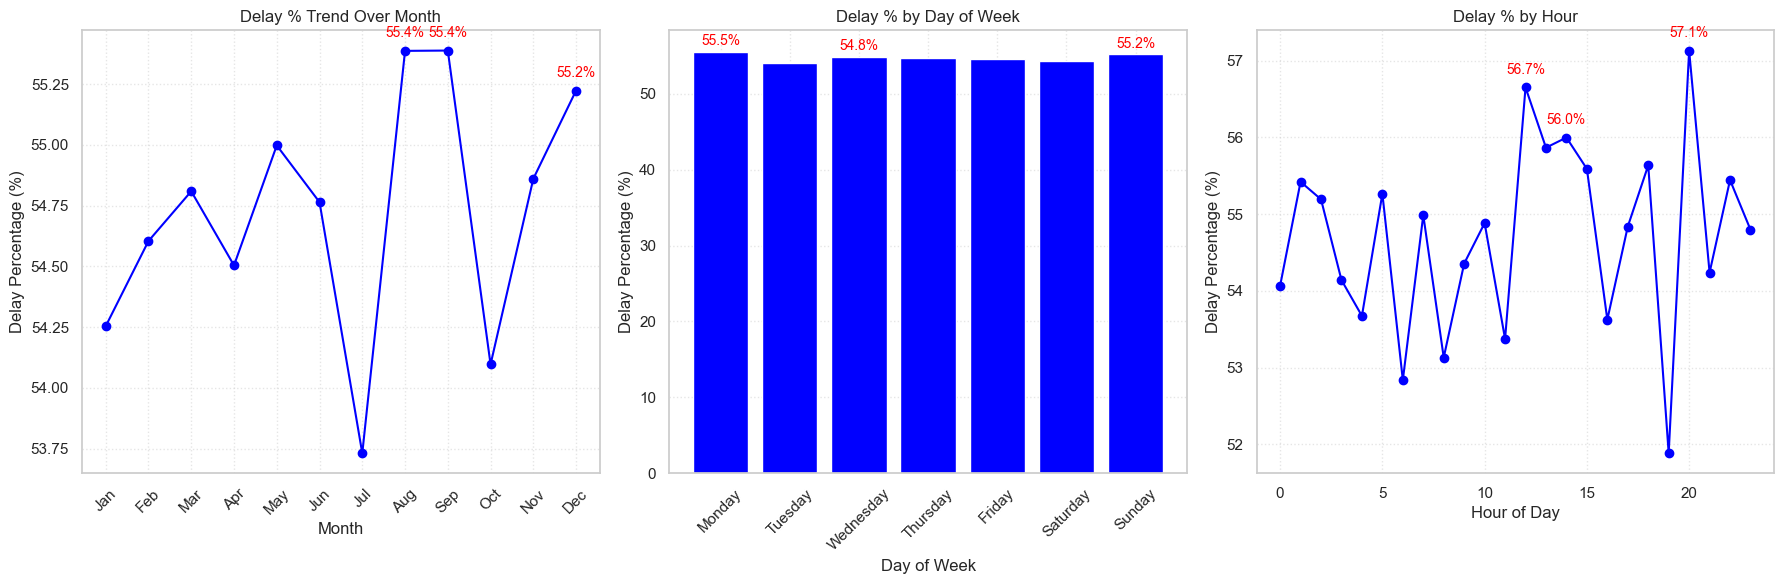

In [26]:
# Define colors used in the script
primary_color = 'blue'
danger_color = 'red'

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# --- Subplot 1: Delay % Trend Over Month ---
ax1.plot(delay_by_month['order month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# --- Subplot 2: Delay % by Day of Week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order day'] = pd.Categorical(delay_by_day['order day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order day')

ax2.bar(delay_by_day['order day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# --- Subplot 3: Delay % by Hour ---
ax3.plot(delay_by_hour['order hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [30]:
X = df1[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'order month', 'order hour']]
y = df1['Late_delivery_risk']

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# use encoded features for modeling
X = X_encoded

# train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


C:\Users\Asus\AppData\Local\Temp\ipykernel_21172\547839853.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [31]:
# Balancing the training data using SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [32]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall:", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [33]:
models = {
    "Logistic Regression": LogisticRegression(),
    "XGBoost": XGBClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    preds = model.predict(X_test)
    evaluate_model(y_test, preds, name)


--- Logistic Regression ---
Accuracy: 0.7
Precision: 0.83
Recall: 0.59

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.84      0.70     14758
           1       0.83      0.59      0.69     19795

    accuracy                           0.70     34553
   macro avg       0.72      0.72      0.70     34553
weighted avg       0.74      0.70      0.70     34553


--- XGBoost ---
Accuracy: 0.73
Precision: 0.87
Recall: 0.61

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.88      0.73     14758
           1       0.87      0.61      0.72     19795

    accuracy                           0.73     34553
   macro avg       0.75      0.75      0.73     34553
weighted avg       0.77      0.73      0.73     34553


--- Random Forest ---
Accuracy: 0.74
Precision: 0.78
Recall: 0.75

Classification Report:
               precision    recall  f1-score   support

           0    